In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.measure import regionprops_table
from cellpose_omni import models
import trackpy as tp

In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

CUDA available: True
Device: NVIDIA GeForce RTX 3070 Laptop GPU


Frame 99: 209 trajectories present.
Linked trajectories: 759
count    759.000000
mean      29.259552
std       37.720886
min        1.000000
25%        2.000000
50%        7.000000
75%       51.500000
max      100.000000
Name: frame, dtype: float64
Tracks >= 10 frames: 347
Tracks >= 20 frames: 274
Particles after track-length filter: 375
Rows after filtering: 21366
Removed jumpy tracks: 0
Particles after jump filter: 375


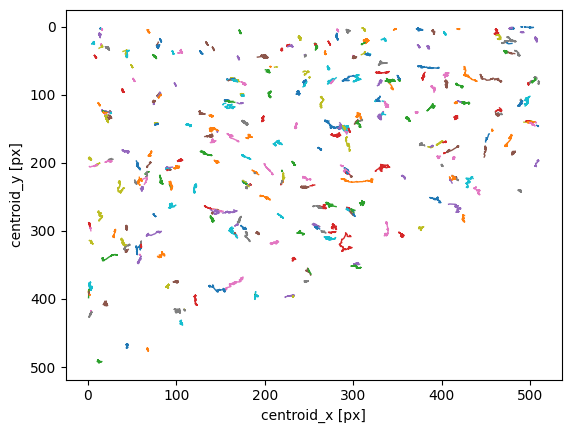

Overall mean speed: 0.646124633123 pixels/frame
Overall mean speed: 0.215374016208 um/frame
Saved overlay video: C:\Users\Kira Kawczynski\full code\omnipose_tracks_overlayfinal.avi


In [3]:
#1
video_path = r"C:\Users\Kira Kawczynski\full code\jb.00184-19-sm009_resized.avi"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise FileNotFoundError("Could not open video. Check the path.")

frames = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)
    frames.append(gray)

cap.release()

# limit after loading
frames = frames[:100]

print("Frames loaded:", len(frames))
print("Frame shape:", frames[0].shape)

#2
model = models.CellposeModel(
    gpu=True,                 # change to True if GPU works
    model_type="cyto2",
    omni=True
)

masks, flows, styles = model.eval(
    frames,
    channels=[0, 0],
    diameter=6,
    omni=True,
    flow_threshold=0.0,
    cellprob_threshold=0.0,
    mask_threshold=0.4,
    batch_size=1
)

#3
i = 10

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(frames[i], cmap="gray")
plt.title("Original frame")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(masks[i], cmap="nipy_spectral")
plt.title("Omnipose masks")
plt.axis("off")

plt.show()

#4
all_props = []

for frame_idx, mask in enumerate(masks):
    props = regionprops_table(
        mask,
        properties=[
            "label",
            "area",
            "centroid",
            "major_axis_length",
            "minor_axis_length"
        ]
    )

    df_frame = pd.DataFrame(props)

    if len(df_frame) == 0:
        continue

    df_frame = df_frame.rename(columns={
        "centroid-0": "centroid_y",
        "centroid-1": "centroid_x"
    })

    df_frame["frame"] = frame_idx
    all_props.append(df_frame)

omni_df = pd.concat(all_props, ignore_index=True)

print(omni_df.head())
print("Total detections:", len(omni_df))
print("Frames represented:", omni_df["frame"].nunique())

#5
filtered = omni_df[
    (omni_df["area"] > 8) &
    (omni_df["area"] < 180) &
    (omni_df["major_axis_length"] > 5) &
    (omni_df["major_axis_length"] < 35) &
    (omni_df["minor_axis_length"] < 18)
].copy()

print("After filtering:", len(filtered))
print(filtered[["area", "major_axis_length", "minor_axis_length"]].describe())

#6
linked = tp.link_df(
    filtered,
    search_range=5,
    memory=2,
    pos_columns=["centroid_x", "centroid_y"],
    t_column="frame"
)

print("Linked trajectories:", linked["particle"].nunique())

track_lengths = linked.groupby("particle")["frame"].nunique()
print(track_lengths.describe())
print("Tracks >= 10 frames:", (track_lengths >= 10).sum())
print("Tracks >= 20 frames:", (track_lengths >= 20).sum())

#7
min_frames = 8

good_particles = track_lengths[track_lengths >= min_frames].index
linked_filtered = linked[linked["particle"].isin(good_particles)].copy()

print("Particles after track-length filter:", linked_filtered["particle"].nunique())
print("Rows after filtering:", len(linked_filtered))

# --- jump filter ---
linked_filtered = linked_filtered.sort_values(["particle", "frame"]).copy()

linked_filtered["dx"] = linked_filtered.groupby("particle")["centroid_x"].diff()
linked_filtered["dy"] = linked_filtered.groupby("particle")["centroid_y"].diff()
linked_filtered["step_distance"] = np.sqrt(
    linked_filtered["dx"]**2 + linked_filtered["dy"]**2
)

max_allowed_jump = 9  # try 6–8 if needed

bad_particles = linked_filtered.loc[
    linked_filtered["step_distance"] > max_allowed_jump,
    "particle"
].unique()

linked_filtered = linked_filtered[
    ~linked_filtered["particle"].isin(bad_particles)
].copy()

print("Removed jumpy tracks:", len(bad_particles))
print("Particles after jump filter:", linked_filtered["particle"].nunique())

#8
ax = tp.plot_traj(
    linked_filtered,
    pos_columns=["centroid_x", "centroid_y"],
    t_column="frame"
)

ax.invert_yaxis()
ax.set_title("Omnipose + TrackPy trajectories")
plt.show()

#9
pixel_scale_factor = 0.333332

df = linked_filtered.sort_values(["particle", "frame"]).copy()

df["dx"] = df.groupby("particle")["centroid_x"].diff()
df["dy"] = df.groupby("particle")["centroid_y"].diff()
df["dt"] = df.groupby("particle")["frame"].diff()

df["speed_pixels_per_frame"] = np.sqrt(df["dx"]**2 + df["dy"]**2) / df["dt"]
df["speed_um_per_frame"] = df["speed_pixels_per_frame"] * pixel_scale_factor

speed_df = df.dropna(subset=["speed_pixels_per_frame"])

speed_df.to_csv("omnipose_particle_speeds.csv", index=False)

mean_speeds = speed_df.groupby("particle")[["speed_pixels_per_frame", "speed_um_per_frame"]].mean()
mean_speeds.to_csv("omnipose_mean_speeds.csv")

print("Overall mean speed:", speed_df["speed_pixels_per_frame"].mean(), "pixels/frame")
print("Overall mean speed:", speed_df["speed_um_per_frame"].mean(), "um/frame")

#10
output_video = r"C:\Users\Kira Kawczynski\full code\omnipose_tracks_overlayfinal.avi"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"XVID")
out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

# Group track points by frame
points_by_frame = {
    frame: group for frame, group in linked_filtered.groupby("frame")
}

# Store trajectory history
history = {}

frame_idx = 0

max_frames = len(frames)

while frame_idx < max_frames:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx in points_by_frame:
        current_points = points_by_frame[frame_idx]

        for _, row in current_points.iterrows():
            pid = int(row["particle"])
            x = int(row["centroid_x"])
            y = int(row["centroid_y"])

            if pid not in history:
                history[pid] = []

            history[pid].append((x, y))

    # Draw trajectories up to current frame
    for pid, pts in history.items():
        if len(pts) > 1:
            for j in range(1, len(pts)):
                cv2.line(frame, pts[j - 1], pts[j], (0, 255, 0), 1)

        if len(pts) > 0:
            cv2.circle(frame, pts[-1], 3, (0, 0, 255), -1)

    out.write(frame)
    frame_idx += 1

cap.release()
out.release()

print("Saved overlay video:", output_video)

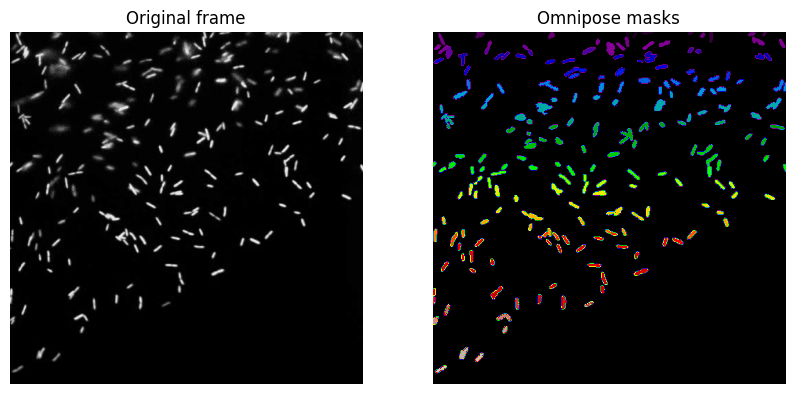

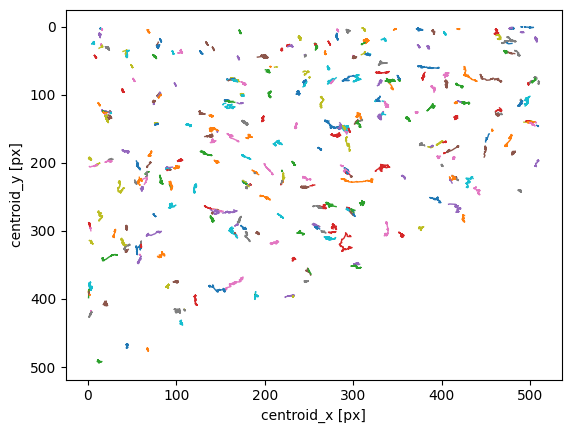

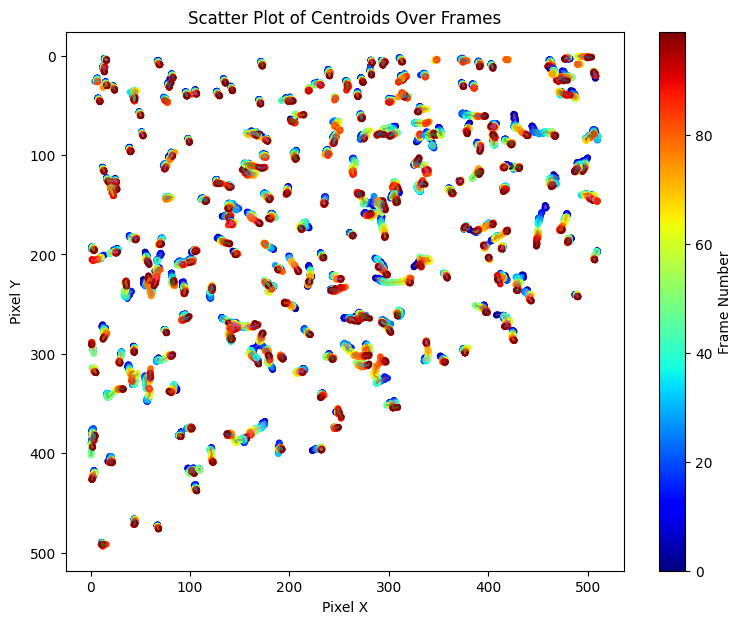

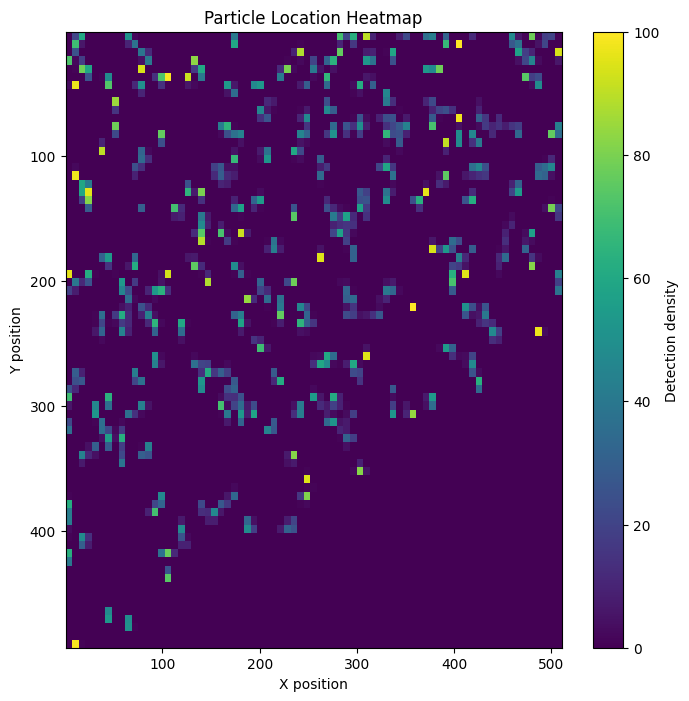

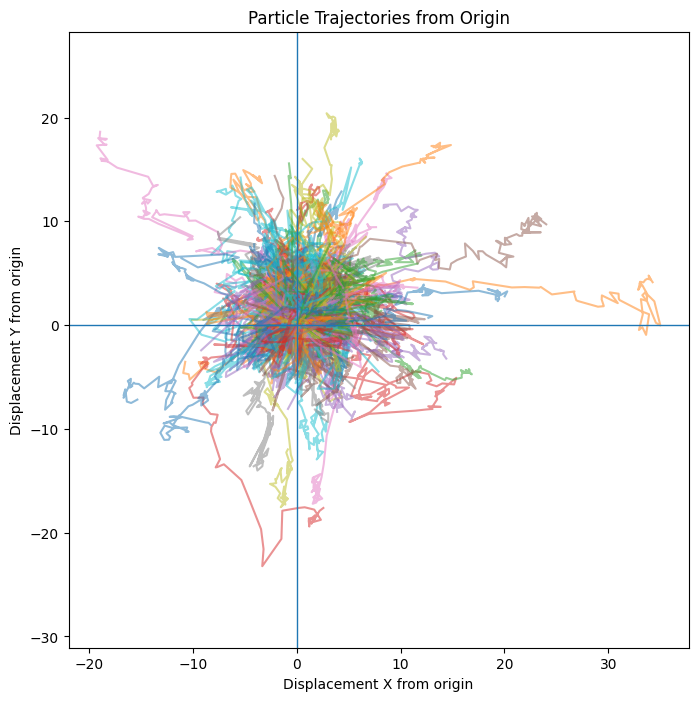

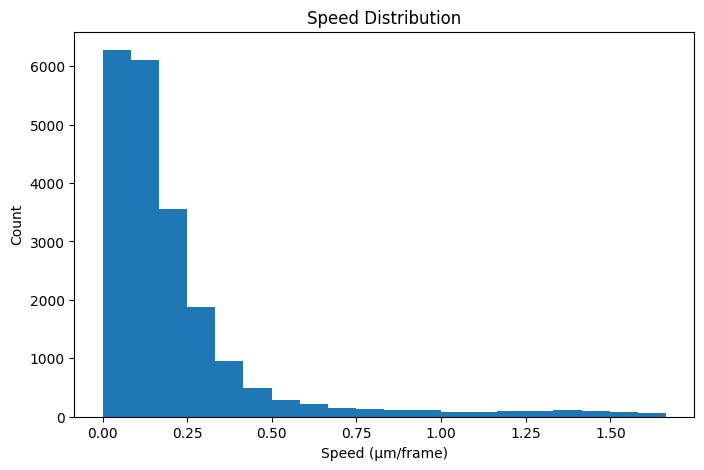

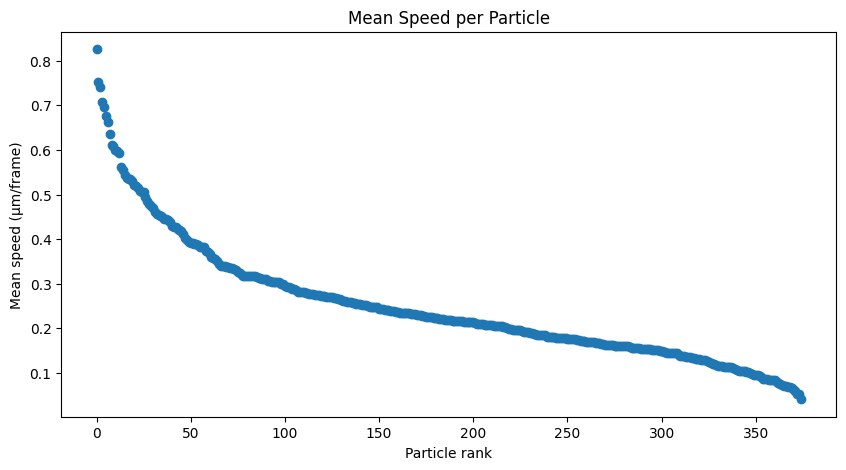

In [5]:
# 11 omnipose mask display
i = 10

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(frames[i], cmap="gray")
plt.title("Original frame")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(masks[i], cmap="nipy_spectral")
plt.title("Omnipose masks")
plt.axis("off")

plt.show()

#12 track trajectories
ax = tp.plot_traj(
    linked_filtered,
    pos_columns=["centroid_x", "centroid_y"],
    t_column="frame"
)
ax.invert_yaxis()
ax.set_title("Particle Trajectories")
plt.show()

#added
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

for particle_id, group in linked_filtered.groupby("particle"):
    group = group.sort_values("frame")
    plt.plot(
        group["centroid_x"],
        group["centroid_y"],
        linewidth=1,
        alpha=0.5
    )

scatter = plt.scatter(
    linked_filtered["centroid_x"],
    linked_filtered["centroid_y"],
    c=linked_filtered["frame"],
    cmap="jet",
    s=14
)

plt.gca().invert_yaxis()
plt.xlabel("Pixel X")
plt.ylabel("Pixel Y")
plt.title("Scatter Plot of Centroids Over Frames")

cbar = plt.colorbar(scatter)
cbar.set_label("Frame Number")

plt.show()
#13 heatmap
plt.figure(figsize=(8, 8))

plt.hist2d(
    linked_filtered["centroid_x"],
    linked_filtered["centroid_y"],
    bins=75
)

plt.gca().invert_yaxis()
plt.colorbar(label="Detection density")
plt.xlabel("X position")
plt.ylabel("Y position")
plt.title("Particle Location Heatmap")
plt.show()

#14 trajectories from origin
plt.figure(figsize=(8, 8))

for particle_id, group in linked_filtered.groupby("particle"):
    group = group.sort_values("frame")

    x0 = group["centroid_x"].iloc[0]
    y0 = group["centroid_y"].iloc[0]

    x_relative = group["centroid_x"] - x0
    y_relative = group["centroid_y"] - y0

    plt.plot(x_relative, y_relative, alpha=0.5)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("Displacement X from origin")
plt.ylabel("Displacement Y from origin")
plt.title("Particle Trajectories from Origin")
plt.axis("equal")
plt.show()

#15 speed histogram
plt.figure(figsize=(8, 5))

plt.hist(speed_df["speed_um_per_frame"], bins=20)

plt.xlabel("Speed (µm/frame)")
plt.ylabel("Count")
plt.title("Speed Distribution")
plt.show()

#16 mean speed per partiicle scatter/ranking
mean_speeds = speed_df.groupby("particle")["speed_um_per_frame"].mean().reset_index()
mean_speeds = mean_speeds.sort_values("speed_um_per_frame", ascending=False)

plt.figure(figsize=(10, 5))
plt.scatter(range(len(mean_speeds)), mean_speeds["speed_um_per_frame"])

plt.xlabel("Particle rank")
plt.ylabel("Mean speed (µm/frame)")
plt.title("Mean Speed per Particle")
plt.show()